# Part 2 (of 3): Temperature Calibration for HI Spectroscopy

This notebook is the **Part-2 calibration stage** in a three-part investigation of the Milky Way HI profile.
Its role is to convert measured PSD/count units into a physically interpretable temperature scale and export a calibration artifact consumed by downstream science analysis.

## Position in the 3-part workflow

1. **Part 1**: instrument/signal-chain characterization and observing setup.
2. **Part 2 (this notebook)**: hot/cold temperature calibration, uncertainty decomposition, and export of calibration products.
3. **Part 3**: velocity-frame correction, baseline subtraction, Gaussian decomposition, and astrophysical interpretation.

## Requirement traceability

This notebook is aligned to:

- `src/ugradio/lab_bighorn/bighorn.tex`
  - hot/cold (blackbody vs cold-sky) intensity calibration context,
  - system-temperature decomposition and absolute temperature scaling goals.
- `src/ugradio/lab_bighorn/cal_intensity.tex`
  - $P_j = G_j\,T_{\mathrm{sys}}(\nu)$ model,
  - cool-method idea: shape ratio times a single scalar temperature scale,
  - first-order error-propagation treatment.
- `src/ugradio/lab_bighorn/horn_signal_chain_test.tex`
  - use of measured signal-chain behavior via required ingest of `equipment_calibration_results_v2.npz`.

`coords.tex` (rotation-matrix coordinate transforms) is out of scope here and handled in downstream analysis notebooks.


## Global assumptions, priors, and scope

- Two-load calibration constants used in this notebook:
  - `T_HOT = 310 K` (human-body blackbody proxy filling the horn aperture).
  - `T_COLD = 30 K` (effective cold-sky reference for this setup/pointing).
- Load-prior uncertainties:
  - `SIGMA_T_HOT = 5 K`, `SIGMA_T_COLD = 2 K`.
- Hardware artifact dependency is hard-gated:
  - `equipment_calibration_results_v2.npz` must exist and pass schema checks.
- Beam-filling default is `eta_bf = 1.0`, so by default reported brightness-equivalent temperature satisfies
  $$T_{B,\mathrm{eq}} = T_A.$$ 
- Horn geometry and $\lambda^2/A$ are retained as diagnostics, not direct Y-factor multipliers.
- RFI handling uses residual sigma clipping after Savitzky-Golay baseline estimation.

### Scope boundary for this Part-2 notebook

This notebook calibrates $T_{\mathrm{rx}}$, $T_{\mathrm{sys}}$, and frequency-dependent temperature scaling products.
Full astrophysical profile extraction (velocity-frame products, baseline/line modeling, aperture-efficiency inference) is part of downstream analysis.


## Radiometric model and derivation used in code

### 1) Backend model

Following `cal_intensity.tex`, measured channel power is modeled as

$$
P_j = G_j\,T_{\mathrm{sys}}(\nu),
$$

with channel-dependent gain $G_j$ and system temperature contributions.

### 2) Two-load Y-factor solve

For hot/cold measurements through the same chain,

$$
Y \equiv \frac{P_{\mathrm{hot}}}{P_{\mathrm{cold}}}
= \frac{T_{\mathrm{hot}}+T_{\mathrm{rx}}}{T_{\mathrm{cold}}+T_{\mathrm{rx}}},
$$

which gives

$$
T_{\mathrm{rx}} = \frac{T_{\mathrm{hot}} - YT_{\mathrm{cold}}}{Y - 1},
\qquad
T_{\mathrm{sys}} = T_{\mathrm{cold}} + T_{\mathrm{rx}}.
$$

### 3) Explicit equivalence to cool-method scalar scaling

Using $Y=P_{\mathrm{hot}}/P_{\mathrm{cold}}$,

$$
T_{\mathrm{sys}} = \frac{T_{\mathrm{hot}}-T_{\mathrm{cold}}}{Y-1}
= \frac{P_{\mathrm{cold}}}{P_{\mathrm{hot}}-P_{\mathrm{cold}}}(T_{\mathrm{hot}}-T_{\mathrm{cold}}),
$$

which is the same scalar factor used by the cool-method derivation when numerator/denominator are evaluated on the same channel set.

### 4) Frequency-dependent antenna-temperature mapping

With a cold-reference profile $P_{\mathrm{cold,ref}}(\nu)$,

$$
T_A(\nu) = P_{\mathrm{obs}}(\nu)\,\frac{T_{\mathrm{cold}}+T_{\mathrm{rx}}}{P_{\mathrm{cold,ref}}(\nu)} - T_{\mathrm{rx}}.
$$

At 1.42 GHz, Rayleigh-Jeans is an excellent approximation for this lab context, so temperature-domain reporting is physically well motivated.


## Error propagation and validity conditions

### Error model used here

Per `cal_intensity.tex`, first-order propagation follows:

- For sums/differences: $\sigma_q^2 = \sigma_x^2 + \sigma_y^2$.
- For products/ratios: $\left(\sigma_q/q\right)^2 = \left(\sigma_x/x\right)^2 + \left(\sigma_y/y\right)^2$.

Implemented uncertainty decomposition for $T_{\mathrm{rx}}$:

- `sigma_T_rx_meas`: propagated measurement term from $P_{\mathrm{hot}}$, $P_{\mathrm{cold}}$ via $Y$.
- `sigma_T_rx_loads`: load-prior term from `SIGMA_T_HOT`, `SIGMA_T_COLD`.
- `sigma_T_rx_hw`: hardware-systematic term from equipment linearity/chain diagnostics.
- `sigma_T_rx_total`: quadrature sum of the three terms.

### Conditions enforced in this notebook

- finite, positive powers in ratio operations,
- physical Y-factor domain $Y>1$,
- common-mask solve policy for hot/cold equivalence checks,
- explicit masking of invalid/RFI channels before scalar solves.


In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display

LAB02_DIR = Path.cwd().resolve()
if not (LAB02_DIR / "utils").exists():
    LAB02_DIR = (Path.cwd() / "labs" / "02").resolve()
if str(LAB02_DIR) not in sys.path:
    sys.path.insert(0, str(LAB02_DIR))

pd.options.display.max_columns = 200
pd.options.display.float_format = "{:.4f}".format

from utils import run_temperature_calibration
from utils.plotting import figure
from utils.tables import table

/Users/junruiting/GitHub/ay-121/.venv/lib/python3.14/site-packages/rtlsdr/__init__.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## Helper functions and implementation modules

These helpers implement the derivations above in reusable numerical operators:

- I/O and artifact schema validation (`load_lo_pair`, `load_equipment_artifact`, `validate_equipment_schema`).
- Masking and robust power summaries (`sigma_clip_rfi_mask`, `masked_total_power`, `masked_mean_power`).
- Hardware-response mapping/correction (`hardware_response_on_axis`, `apply_hardware_response_correction`).
- Calibration primitives (`measure_y_factor`, `build_cold_reference_profile`, `antenna_temp_scale`).


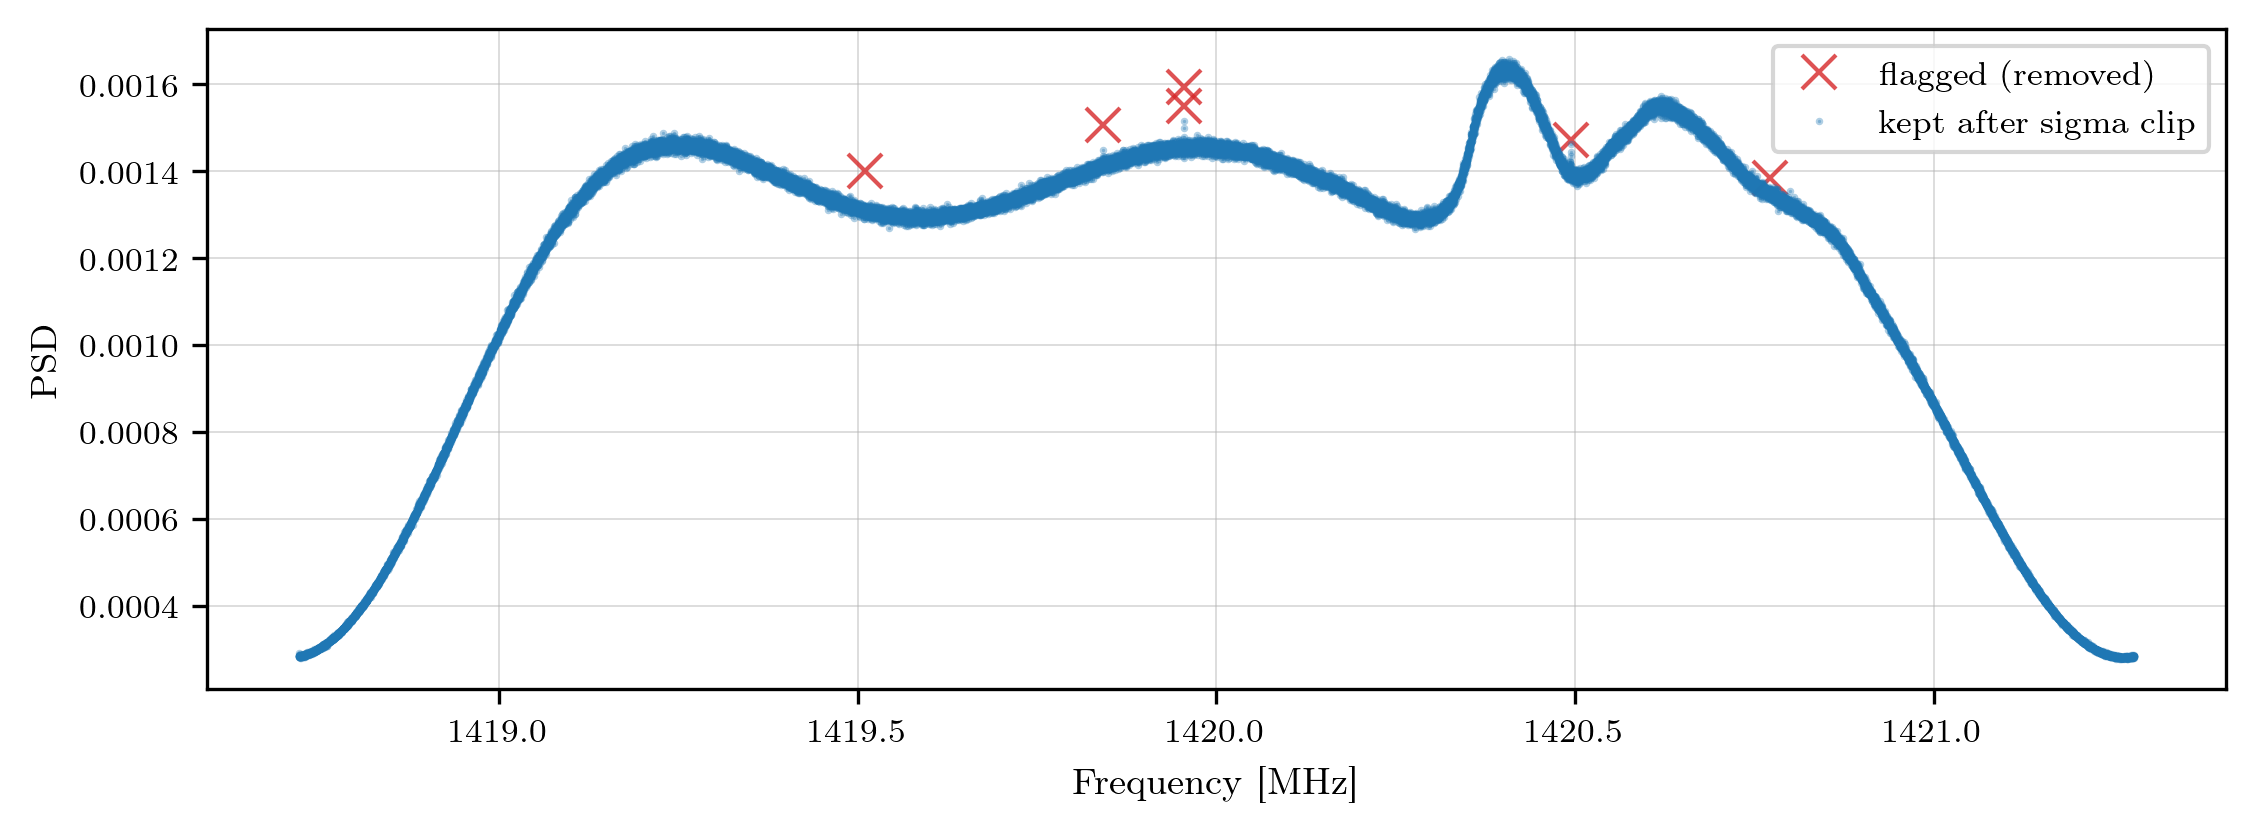

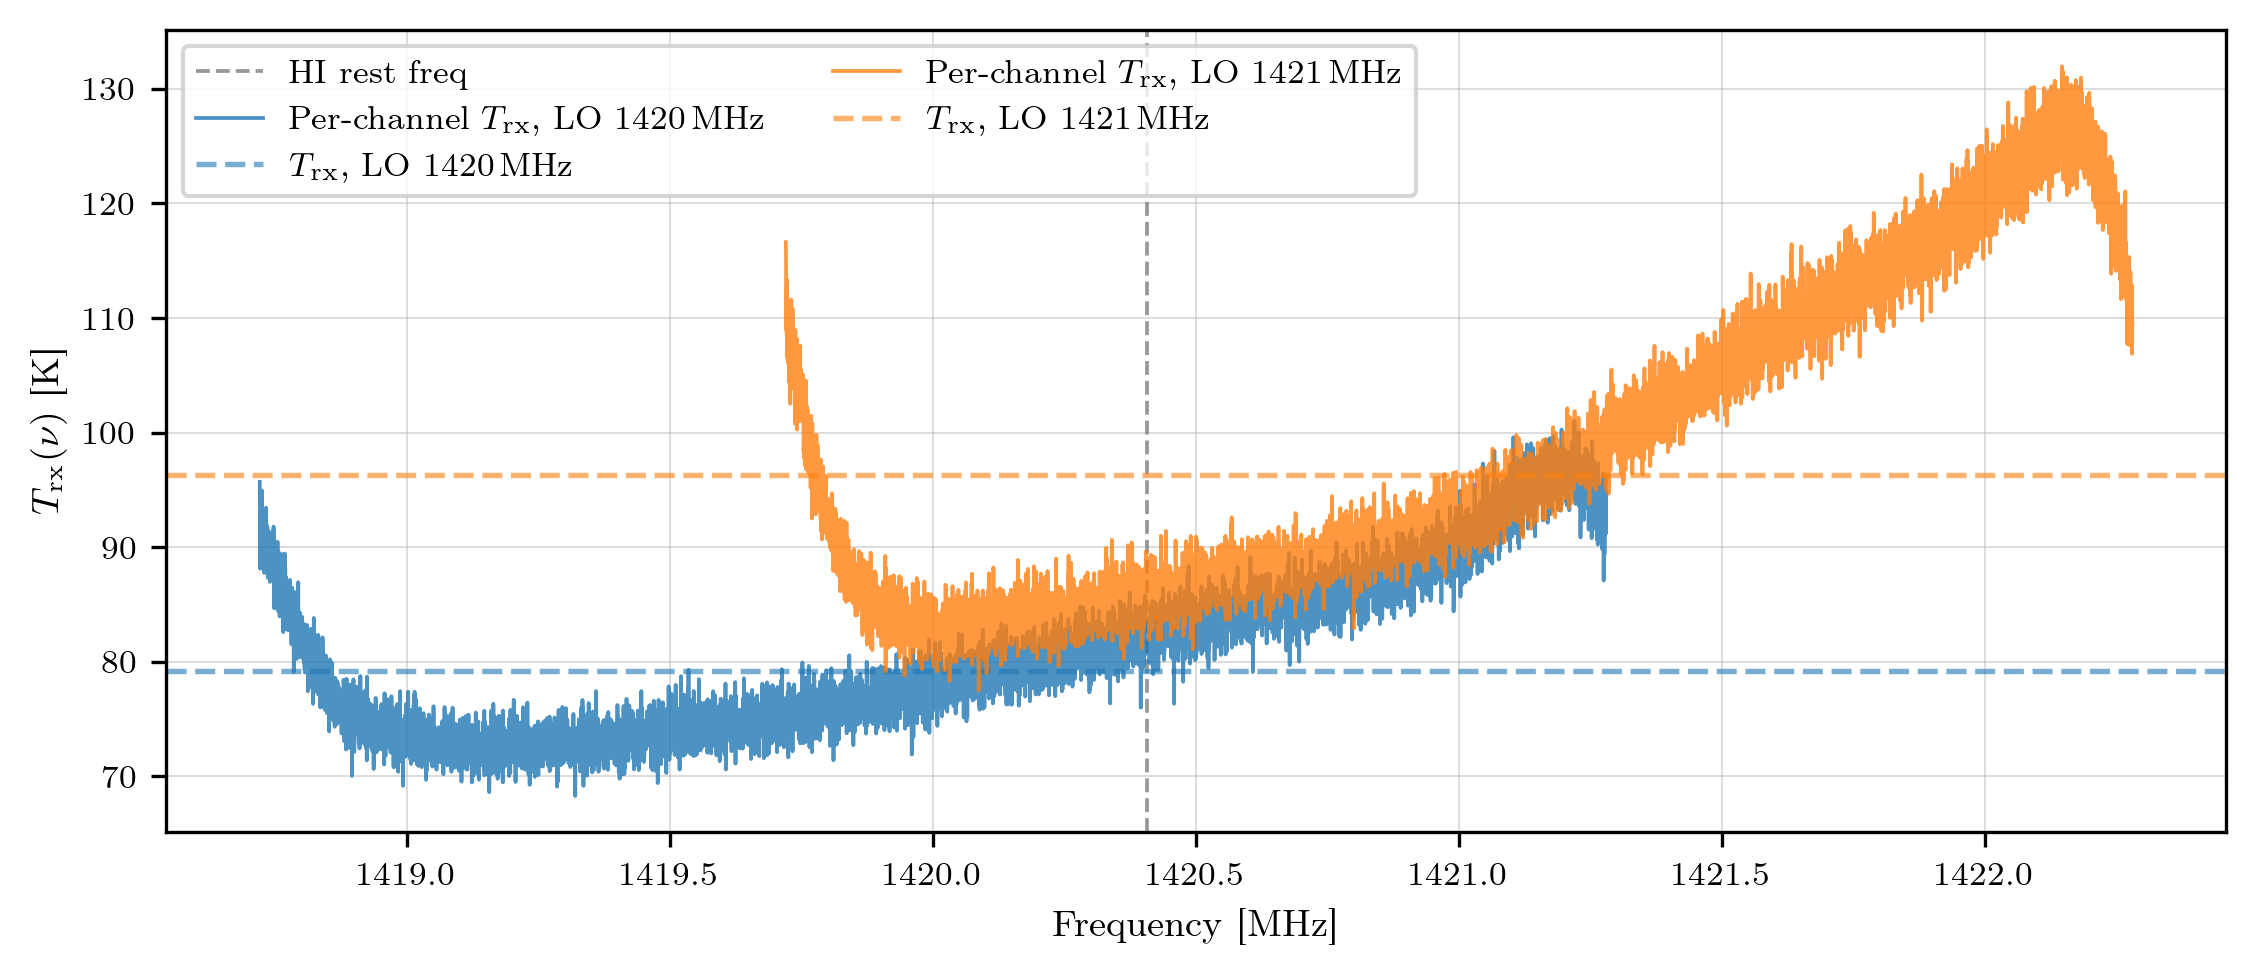

Part 2 produced `3` tables and `2` figures. Artifact: `/Users/junruiting/GitHub/ay-121/labs/02/cache/calibration_results_v2.npz`

In [2]:
temperature = run_temperature_calibration()
display(Markdown(
    f"Part 2 produced `{len(temperature.tables)}` tables and `{len(temperature.figures)}` figures. "
    f"Artifact: `{temperature.artifact_path}`"
))

## Data quality gating: RFI mask ∩ hardware-valid support

Calibration solves use only channels passing both criteria:

1. RFI-clean residual behavior from sigma clipping (`n_sigma = 5`).
2. Finite, non-negligible hardware response support from the equipment artifact.

For illustration we scan every `*_combined_spectra` folder under `data/lab02` and plot only the dataset with the most sigma-clipped bins; good channels appear in blue, flagged bins in low-alpha red.


,T_rx [K],T_cold [K],T_hot [K],Y,Y_dB,P_cold_ref med,P_cold_total,HW frac
LO [MHz],,,,,,,,
1420,79.20 +/- 0.02 (meas) +/- 3.40 (loads) +/- 0.8...,30.0000,310.0000,3.5642,5.520 dB,0.004910,30.9575,0.0113
1421,96.27 +/- 0.02 (meas) +/- 3.68 (loads) +/- 1.0...,30.0000,310.0000,3.2174,5.075 dB,0.005286,33.3716,0.0113


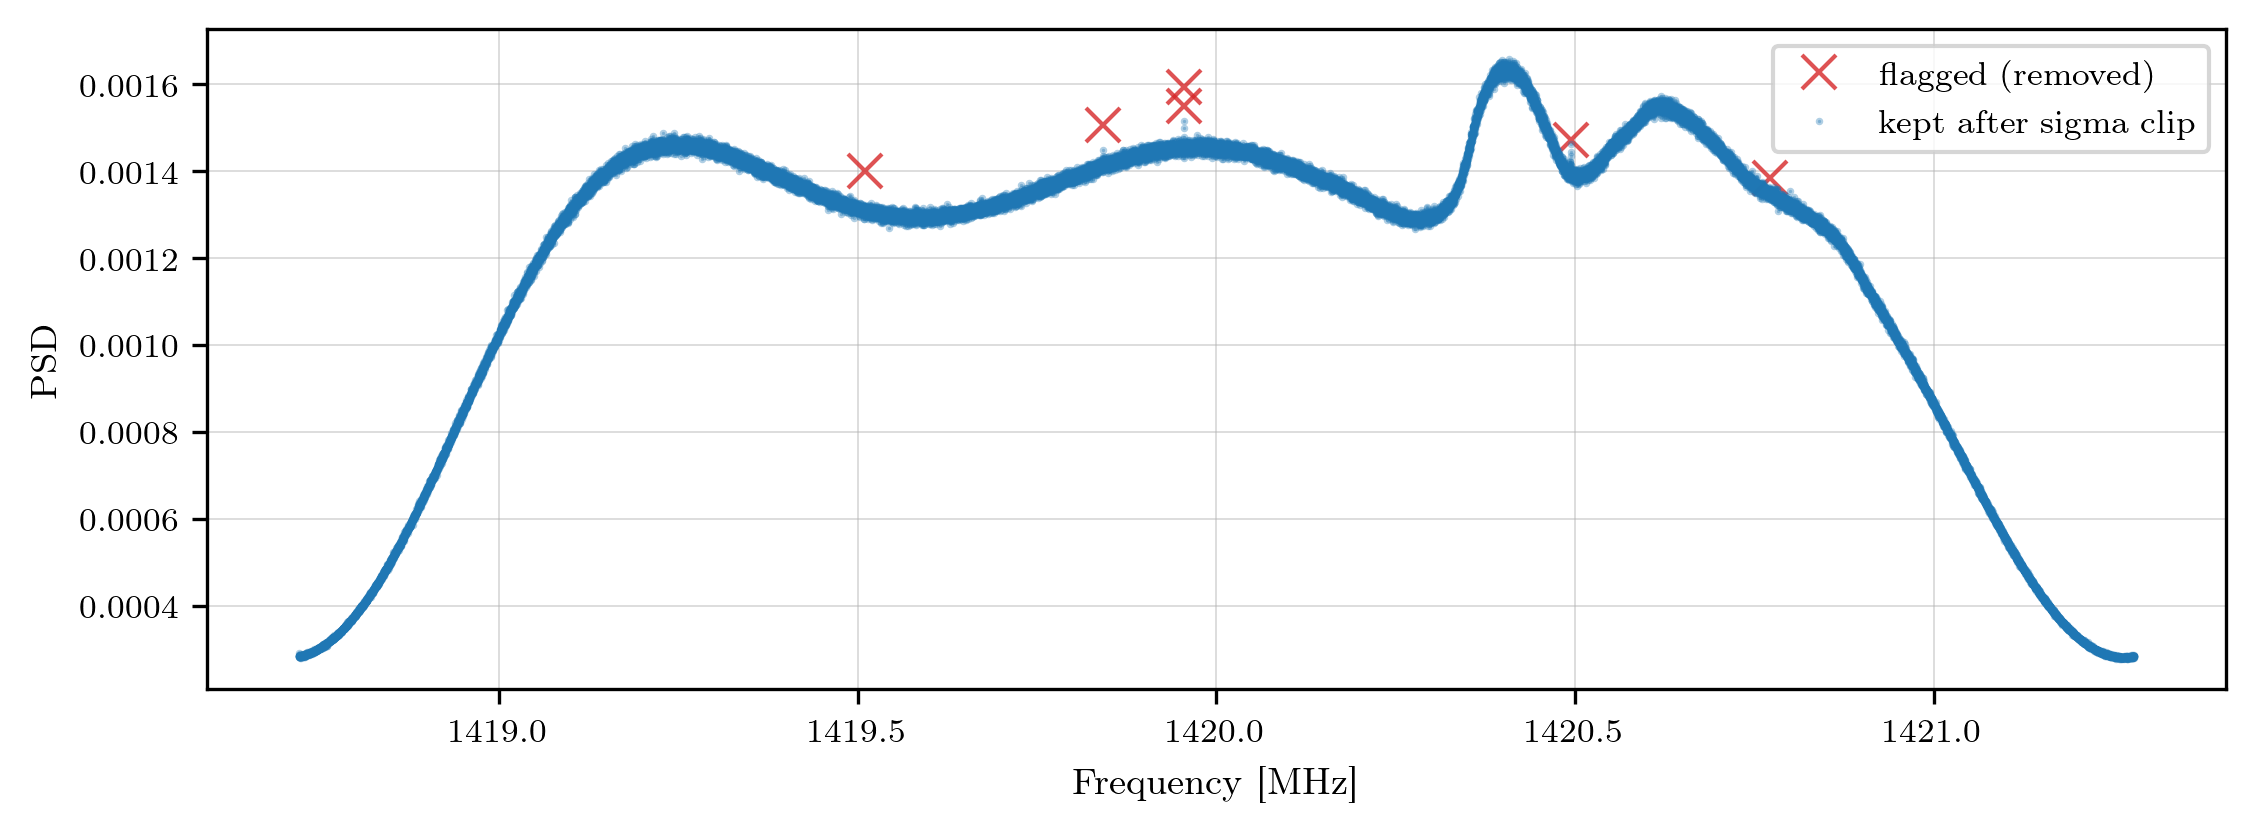

In [3]:
display(table(temperature, "summary"))
display(figure(temperature, "sigma_masking"))

## Y-factor solve (per LO) and uncertainty decomposition

For each LO, the notebook solves

$$
Y = \frac{P_{\mathrm{hot}}}{P_{\mathrm{cold}}},
\qquad
T_{\mathrm{rx}} = \frac{T_{\mathrm{hot}} - Y T_{\mathrm{cold}}}{Y - 1},
$$

using the **common hot/cold mask** for scalar power sums.

Reported outputs include:

- $Y$, $Y_{\mathrm{dB}}$,
- $T_{\mathrm{rx}}$,
- measurement/load/hardware uncertainty components and total quadrature uncertainty.


In [4]:
display(table(temperature, "yfactor_summary"))

,N_common,P_hot,P_cold,Y,Y [dB],T_rx [K],sigma_meas [K],sigma_loads [K],sigma_hw [K],sigma_total [K]
LO [MHz],,,,,,,,,,
1420,8186,110.3375,30.9575,3.564157,5.5196 +/- 0.0005,79.20,0.02,3.40,0.89,3.51
1421,8187,107.3707,33.3716,3.217428,5.0751 +/- 0.0005,96.27,0.02,3.68,1.08,3.83


### Per-channel diagnostics: $Y(\nu)$ and $T_{\mathrm{rx}}(\nu)$

Beyond scalar solves, we inspect channel-wise structure:

- $Y(\nu)=P_{\mathrm{hot}}(\nu)/P_{\mathrm{cold}}(\nu)$,
- implied per-channel $T_{\mathrm{rx}}(\nu)$.

Overlaying LO1420 and LO1421 on a common frequency axis tests overlap-region consistency and reveals edge-response behavior.


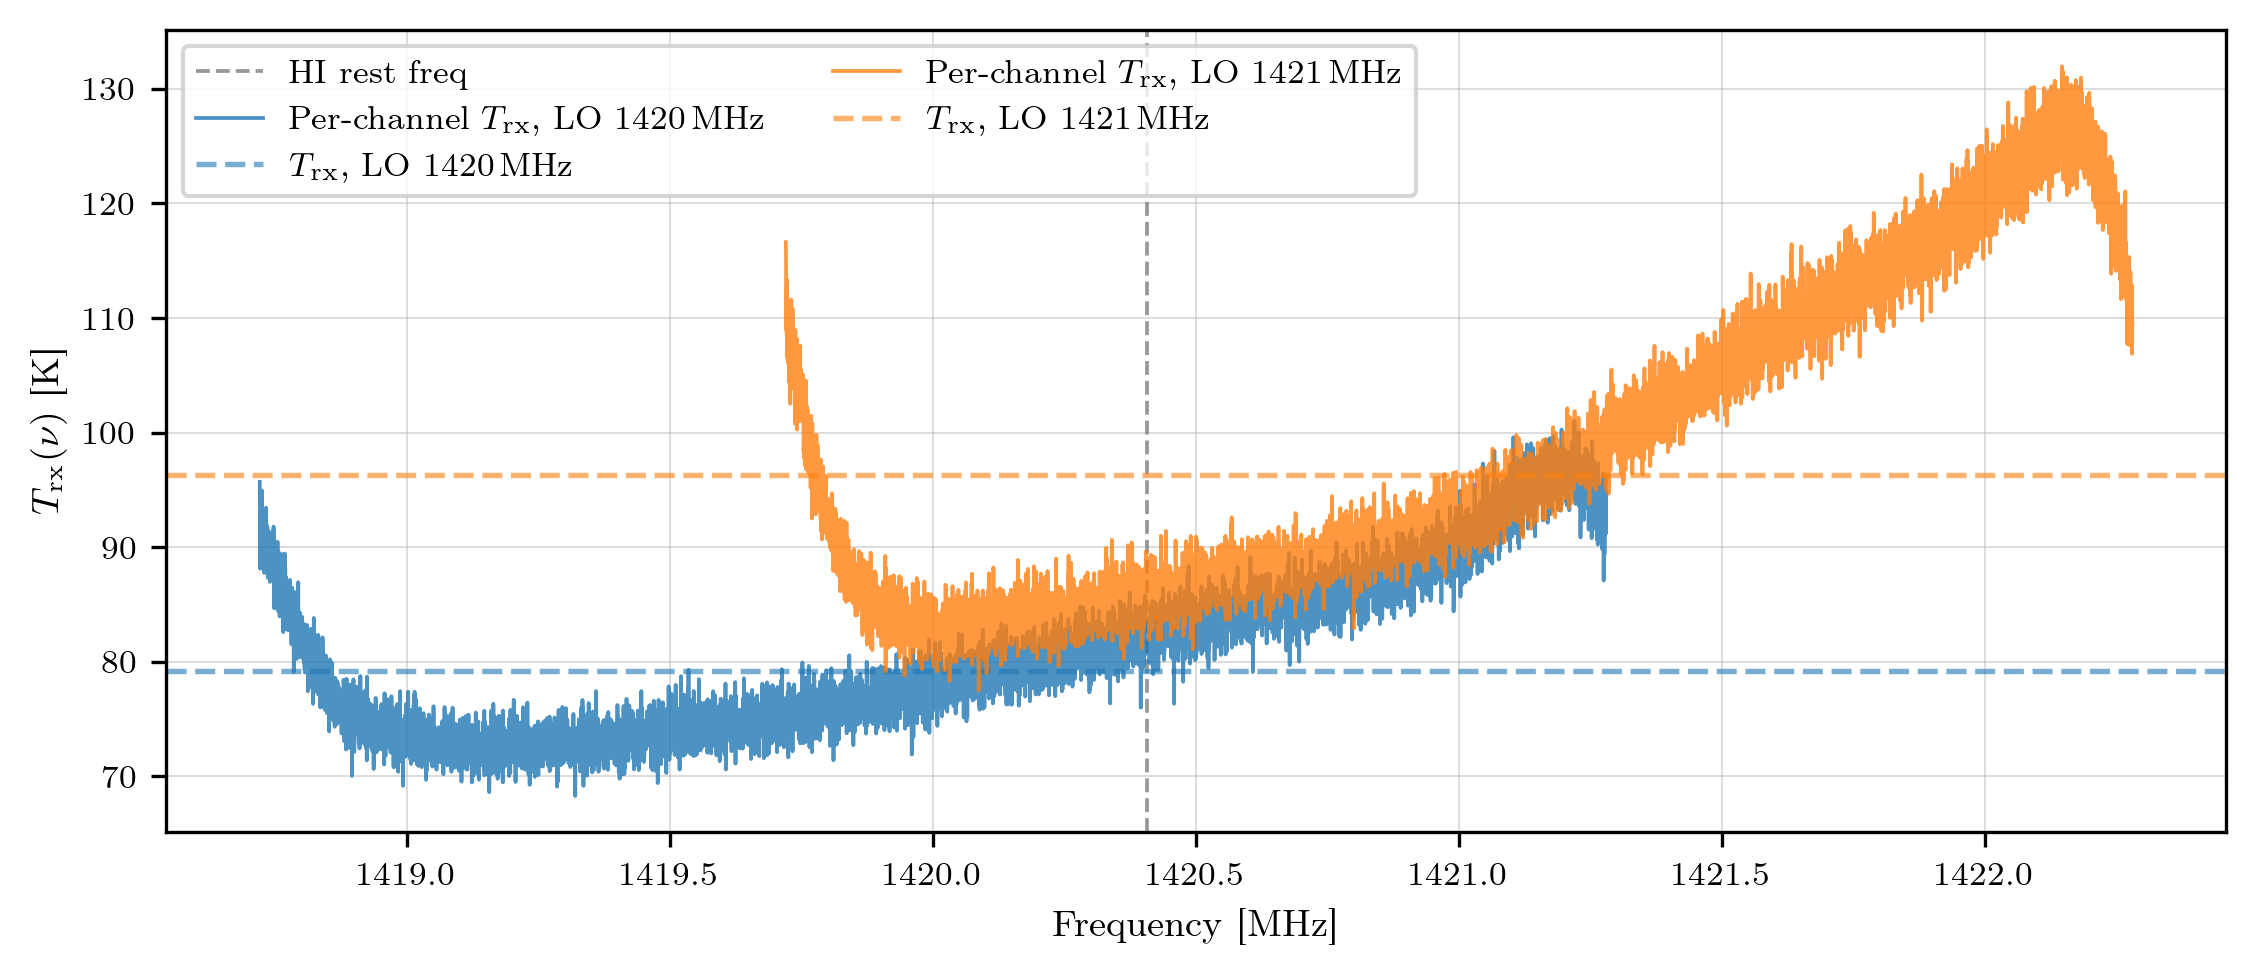

In [5]:
display(figure(temperature, "per_frequency_trx"))

**Observations and interpretation checklist**

- **Smoothness**: $Y(\nu)$ should vary slowly across well-behaved passband regions.
- **Overlap consistency**: LO1420 and LO1421 should broadly agree in their shared frequency region.
- **Edge caution**: deviations near filter roll-off are expected where backend response support declines.
- **Sensitivity near $Y\approx1$**: per-channel $T_{\mathrm{rx}}(\nu)$ scatter is amplified when $(Y-1)$ is small.

Use the printed scalar results from the solve cell as authoritative run-specific values.


## Numerical cross-check: Y-factor vs cool-method scalar form

This diagnostic computes $T_{\mathrm{sys}}$ via two algebraically equivalent paths:

1. Y-factor path: $T_{\mathrm{sys}} = T_{\mathrm{cold}} + T_{\mathrm{rx}}$.
2. Cool-method scalar path:
   $$
   T_{\mathrm{sys}} = \frac{\sum P_{\mathrm{cold}}}{\sum(P_{\mathrm{hot}}-P_{\mathrm{cold}})}(T_{\mathrm{hot}}-T_{\mathrm{cold}}).
   $$

The common-mask comparison should match to numerical precision; separate-mask differences are reported only as diagnostics.


In [6]:
display(table(temperature, "crosscheck"))

,N_common,"T_sys (Y, common mask) [K]","T_sys (cool, common mask) [K]",Delta(common cool - common Y) [K],"T_sys (Y, production masks) [K]",Delta(prod Y - common Y) [K],"T_sys (cool, separate masks) [K]",Delta(separate cool - common Y) [K]
LO [MHz],,,,,,,,
1420,8186,109.1977,109.1977,-0.0000,109.1977,0.0000,109.3100,0.1123
1421,8187,126.2724,126.2724,0.0000,126.2724,0.0000,126.3480,0.0756


## Export calibration contract (`cache/calibration_results_v2.npz`)

This cell writes the downstream calibration artifact and verifies reload integrity.

Science-critical groups persisted in the artifact:

- scalar calibration terms: `t_rx_*`, `sigma_t_rx_*`, `t_hot`, `t_cold`,
- uncertainty decomposition and hardware systematic fraction,
- frequency-dependent cold-reference profiles/masks/frequency axes,
- hardware provenance and mask-strategy metadata,
- diagnostic metadata needed for downstream checks.

The preflight key check at the end confirms downstream analysis compatibility.


In [7]:
hardware = pd.DataFrame([temperature.values["hardware"]]).T.rename(columns={0: "value"})
display(hardware)
display(Markdown(f"Saved `{len(temperature.artifact)}` artifact fields to `{temperature.artifact_path}`."))

,value
path,/Users/junruiting/GitHub/ay-121/labs/02/cache/...
schema_version,2.0.0
alpha_db_per_m,0.7281
sigma_alpha_db_per_m,0.1269
unknown_cable_length_m,40.0589
unknown_cable_length_sigma_m,7.3462
highest_unclipped_setpoint_dbm,13.0000
first_clipped_setpoint_dbm,15.5000
clip_threshold,0.0010
response_floor,0.0100


Saved `69` artifact fields to `/Users/junruiting/GitHub/ay-121/labs/02/cache/calibration_results_v2.npz`.

## Downstream handoff (Part 3 analysis)

Use `cache/calibration_results_v2.npz` as the calibration contract for science extraction notebooks.

Recommended downstream usage:

1. Load `t_rx_*`, `cold_ref_profile_*`, `cold_ref_mask_*`, and `freq_hz_*`.
2. Apply the same validity/masking conventions used during calibration.
3. Build temperature-calibrated line products on the analysis velocity grid.
4. Propagate uncertainty with the same measurement + load-prior + hardware decomposition.
5. Perform baseline modeling, velocity-frame corrections, Gaussian decomposition, and aperture-efficiency inference in the analysis notebook.

Aperture-efficiency estimation is intentionally handled outside this Part-2 calibration notebook.
